# Sales Forecasting
Enhanced notebook: forecasting, evaluation, and visualizations.

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure notebook can import the project package when running from the notebooks folder
ROOT_DIR = Path.cwd().parent.resolve()
sys.path.append(str(ROOT_DIR))

from src.data_processing import load_sales_data, preprocess_time_series, train_test_split_ts
from src.modeling import train_linear_trend, forecast_linear, train_arima, evaluate_forecast
from src.visualization import plot_forecasts, plot_residuals, plot_rolling_error
sns.set(style="whitegrid")
%matplotlib inline

In [ ]:
# Load data
df = load_sales_data('../data/sales_data.csv')
df.head()

In [ ]:
# Preprocess to daily time series
ts = preprocess_time_series(df, freq='D')
ts.plot(title='Sales (daily)', figsize=(12,4))
plt.show()

In [ ]:
# Split into train/test
train, test = train_test_split_ts(ts, test_size=30)
print('Train length:', len(train), 'Test length:', len(test))

In [ ]:
# Fit baseline models
lin_model, intercept = train_linear_trend(train)
pred_lin = forecast_linear(lin_model, steps=len(test), start_index=len(train))
pred_lin = pd.Series(pred_lin, index=test.index)
arima_model = train_arima(train, order=(1,1,1))
pred_arima = arima_model.forecast(steps=len(test))
pred_arima = pd.Series(pred_arima, index=test.index)

In [ ]:
# Evaluate and show metrics
metrics_lin = evaluate_forecast(test, pred_lin)
metrics_arima = evaluate_forecast(test, pred_arima)
print('Linear metrics:', metrics_lin)
print('ARIMA metrics:', metrics_arima)
# ARIMA AIC if available
try:
    print('ARIMA AIC:', arima_model.aic)
except Exception:
    pass

In [ ]:
# Visualizations: forecasts with intervals, residuals, and rolling error
plot_forecasts(train, test, pred_lin, pred_arima, arima_model=arima_model)
plot_residuals(test, pred_arima)
plot_rolling_error(test, pred_arima, window=7)

## Next steps
- Tune ARIMA orders or use automated selection (pmdarima)
- Add holiday/events regressors and external covariates
- Package model and schedule periodic re-training

# Sales Forecasting
Enhanced notebook: forecasting, evaluation, and visualizations.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure notebook can import the project package when running from the notebooks folder
ROOT_DIR = Path.cwd().parent.resolve()
sys.path.append(str(ROOT_DIR))

from src.data_processing import load_sales_data, preprocess_time_series, train_test_split_ts
from src.modeling import train_linear_trend, forecast_linear, train_arima, evaluate_forecast
from src.visualization import plot_forecasts, plot_residuals, plot_rolling_error
sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# Load data
df = load_sales_data('../data/sales_data.csv')
df.head()

,date,sales
0,2026-01-01,100
1,2026-01-02,110
2,2026-01-03,95
3,2026-01-04,120
4,2026-01-05,130


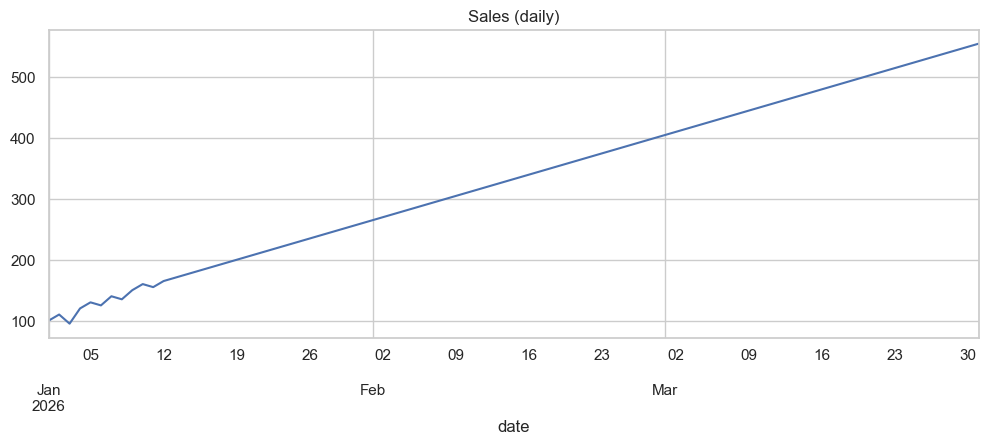

In [3]:
# Preprocess to daily time series
ts = preprocess_time_series(df, freq='D')
ts.plot(title='Sales (daily)', figsize=(12,4))
plt.show()

In [4]:
# Split into train/test
train, test = train_test_split_ts(ts, test_size=30)
print('Train length:', len(train), 'Test length:', len(test))

Train length: 60 Test length: 30


In [5]:
# Fit baseline models
lin_model, intercept = train_linear_trend(train)
pred_lin = forecast_linear(lin_model, steps=len(test), start_index=len(train))
pred_lin = pd.Series(pred_lin, index=test.index)
arima_model = train_arima(train, order=(1,1,1))
pred_arima = arima_model.forecast(steps=len(test))
pred_arima = pd.Series(pred_arima, index=test.index)

c:\Users\jasti\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\jasti\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [6]:
# Evaluate and show metrics
metrics_lin = evaluate_forecast(test, pred_lin)
metrics_arima = evaluate_forecast(test, pred_arima)
print('Linear metrics:', metrics_lin)
print('ARIMA metrics:', metrics_arima)
# ARIMA AIC if available
try:
    print('ARIMA AIC:', arima_model.aic)
except Exception:
    pass

Linear metrics: {'mae': 3.2241131795869666, 'rmse': 3.328863315392482, 'mape_percent': np.float64(0.658036766414256)}
ARIMA metrics: {'mae': 1.3926325220154259, 'rmse': 1.5949337315957735, 'mape_percent': np.float64(0.2763199538454812)}
ARIMA AIC: 365.3872218413815


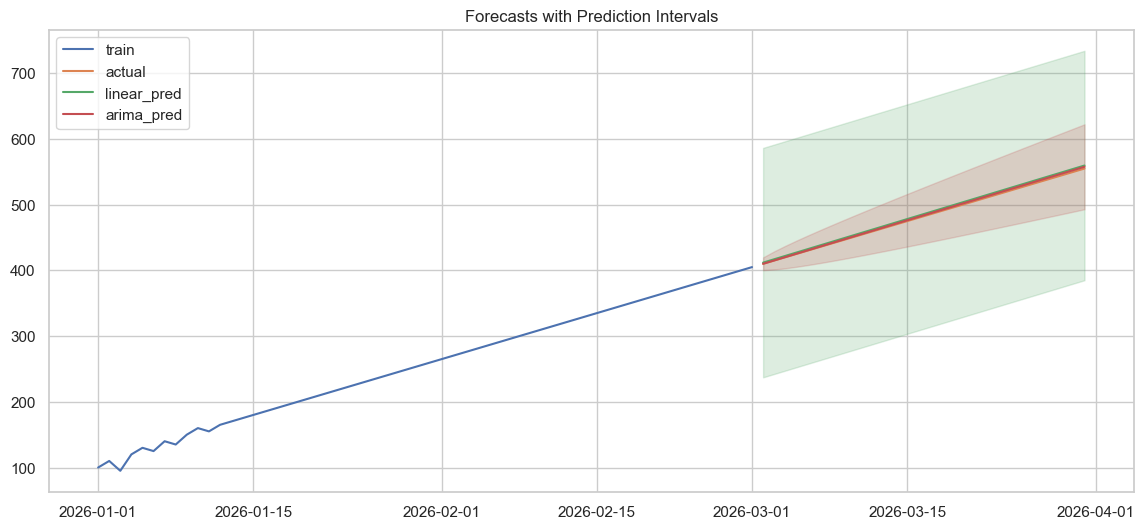

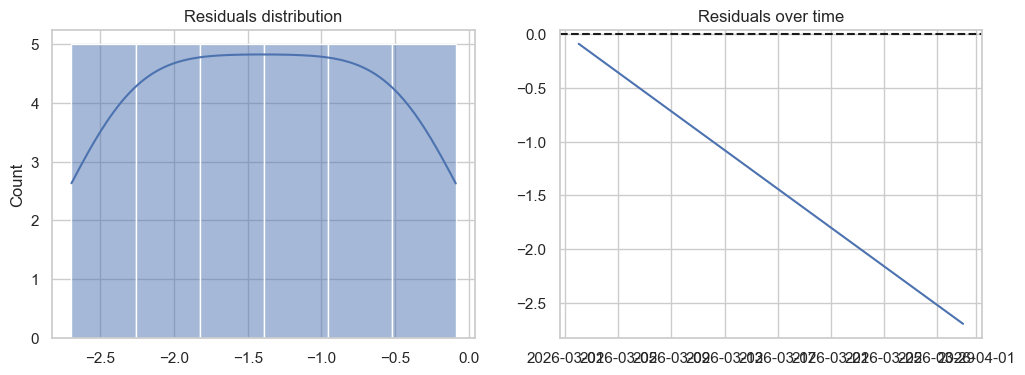

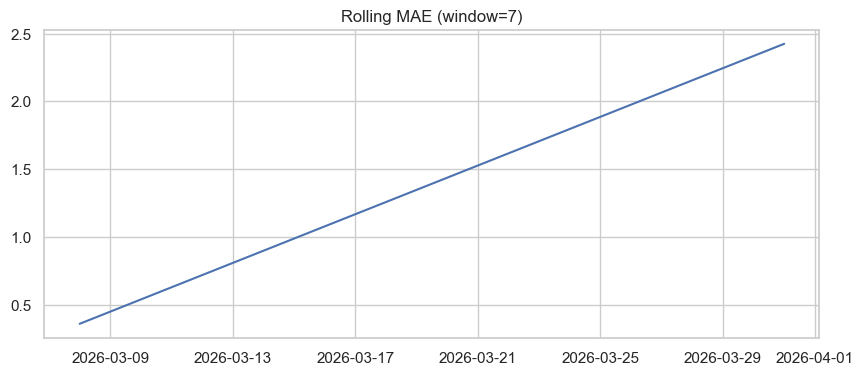

In [7]:
# Visualizations: forecasts with intervals, residuals, and rolling error
plot_forecasts(train, test, pred_lin, pred_arima, arima_model=arima_model)
plot_residuals(test, pred_arima)
plot_rolling_error(test, pred_arima, window=7)

## Next steps
- Tune ARIMA orders or use automated selection (pmdarima)
- Add holiday/events regressors and external covariates
- Package model and schedule periodic re-training